# Project Title: Understanding Factors Affecting Wheat Yield Using FAO and World Bank Data


In [22]:
# =========================
# STEP 1 — Import Libraries
# =========================
import pandas as pd
import numpy as np

# =========================
# STEP 2 — Load FAO Wheat Yield (Target)
# =========================
fao = pd.read_csv("FAOSTAT_data_en_2-16-2026.csv")

# Filter for Wheat and Yield only
fao_wheat = fao[(fao["Item"] == "Wheat") & (fao["Element"] == "Yield")].copy()
fao_wheat = fao_wheat[["Area", "Year", "Value"]]
fao_wheat.columns = ["Country", "Year", "Wheat_Yield_kg_ha"]
fao_wheat["Year"] = pd.to_numeric(fao_wheat["Year"], errors="coerce")
fao_wheat["Wheat_Yield_kg_ha"] = pd.to_numeric(fao_wheat["Wheat_Yield_kg_ha"], errors="coerce")
fao_wheat = fao_wheat[fao_wheat["Year"] >= 2000].dropna().reset_index(drop=True)

# =========================
# STEP 3 — Load World Bank Indicators
# =========================
def load_wb_indicator(file_path, indicator_name, skiprows=4):
    """
    Load a World Bank CSV and convert from wide to long format
    """
    df = pd.read_csv(file_path, skiprows=skiprows)
    
    # Melt to long format
    df_long = df.melt(
        id_vars=["Country Name"], 
        var_name="Year", 
        value_name=indicator_name
    )
    df_long = df_long.rename(columns={"Country Name": "Country"})
    df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")
    df_long[indicator_name] = pd.to_numeric(df_long[indicator_name], errors="coerce")
    df_long = df_long[df_long["Year"] >= 2000].dropna(subset=[indicator_name])
    return df_long[["Country", "Year", indicator_name]]

# Load all indicators
wb_yield = pd.read_csv("WB_WDI_AG_YLD_CREL_KG.csv")[["REF_AREA_LABEL", "TIME_PERIOD", "OBS_VALUE"]]
wb_yield.columns = ["Country", "Year", "Cereal_Yield_kg_ha"]
wb_yield["Year"] = pd.to_numeric(wb_yield["Year"], errors="coerce")
wb_yield["Cereal_Yield_kg_ha"] = pd.to_numeric(wb_yield["Cereal_Yield_kg_ha"], errors="coerce")
wb_yield = wb_yield[wb_yield["Year"] >= 2000].dropna()

land_long = load_wb_indicator("API_AG.LND.AGRI.ZS_DS2_en_csv_v2_174067[1].csv", "Agri_Land_Percent")
fertilizer = load_wb_indicator("fertilizer.csv", "Fertilizer_Use")
arable = load_wb_indicator("Arable land %.csv", "Arable_Land_Percent")

# =========================
# STEP 4 — Merge all datasets
# =========================
data = fao_wheat
for df in [wb_yield, land_long, fertilizer, arable]:
    data = data.merge(df, on=["Country", "Year"], how="inner")
# Merging FAO and World Bank datasets using Country and Year as keys
# This ensures alignment of economic + agricultural indicators

# Drop any remaining missing values
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

# =========================
# STEP 5 — Check final dataset
# =========================
print("Final dataset shape:", data.shape)
print(data.head())


Final dataset shape: (1414, 7)
       Country  Year  Wheat_Yield_kg_ha  Cereal_Yield_kg_ha  \
0  Afghanistan  2000              724.0               806.3   
1  Afghanistan  2001              897.7              1006.7   
2  Afghanistan  2002             1541.9              1669.8   
3  Afghanistan  2003             1500.0              1458.0   
4  Afghanistan  2004             1265.9              1334.8   

   Agri_Land_Percent  Fertilizer_Use  Arable_Land_Percent  
0          57.945817      100.000000            11.779587  
1          57.947350      100.000000            11.779587  
2          57.939684      104.753566            11.771921  
3          58.083805      166.820931            11.916042  
4          58.151266      170.469730            11.983503  


### Data Loading & Preprocessing
First, I imported pandas and numpy for data handling.

Then, I loaded FAO wheat yield data and filtered only:

- Item = Wheat

- Element = Yield

I kept Country, Year, and Yield columns, converted them to numeric format, removed data before 2000, and dropped missing values.
This becomes my **target variable**.

Next, I loaded World Bank indicators:

- Cereal Yield

- Agricultural Land %

- Fertilizer Use

- Arable Land %

I converted them into proper long format and cleaned missing values.

After that, I merged all datasets using Country and Year as common keys.

Finally:

- I removed remaining missing values.

- Reset the index.

- Got a clean dataset with **1414 rows and 7 columns**.

This dataset is fully cleaned and ready for analysis and machine learning.

In [2]:
# Check dataset info
print(data.info())

# Check missing values
print(data.isna().sum())

# Quick glimpse of data
print(data.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1414 entries, 0 to 1413
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              1414 non-null   object 
 1   Year                 1414 non-null   int64  
 2   Wheat_Yield_kg_ha    1414 non-null   float64
 3   Cereal_Yield_kg_ha   1414 non-null   float64
 4   Agri_Land_Percent    1414 non-null   float64
 5   Fertilizer_Use       1414 non-null   float64
 6   Arable_Land_Percent  1414 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 77.5+ KB
None
Country                0
Year                   0
Wheat_Yield_kg_ha      0
Cereal_Yield_kg_ha     0
Agri_Land_Percent      0
Fertilizer_Use         0
Arable_Land_Percent    0
dtype: int64
       Country  Year  Wheat_Yield_kg_ha  Cereal_Yield_kg_ha  \
0  Afghanistan  2000              724.0               806.3   
1  Afghanistan  2001              897.7              1006.7   

### Dataset Verification

After merging the datasets, I checked the dataset information using data.info().

- The dataset contains 1414 rows and 7 columns.

- All columns have correct data types:

**Country → Object**

**Year → Integer**

**Remaining variables → Float**

Next, I checked for missing values using data.isna().sum().

- There are zero missing values in all columns.

Finally, I displayed the first few rows using data.head() to confirm:

- Data is properly merged.

- Country and Year alignment is correct.

- All feature values are present.

- This confirms that the dataset is clean, complete, and ready for analysis and modeling.

In [3]:
# Descriptive statistics
print(data.describe())

# Optional: more readable rounded view
data.describe().round(2)


              Year  Wheat_Yield_kg_ha  Cereal_Yield_kg_ha  Agri_Land_Percent  \
count  1414.000000        1414.000000         1414.000000        1414.000000   
mean   2011.244696        3386.550283         4037.168175          42.663892   
std       6.902379        1848.832203         2808.601805          22.632587   
min    2000.000000         320.000000          309.700000           2.693886   
25%    2005.000000        2034.775000         2412.325000          21.612898   
50%    2011.000000        2988.400000         3602.150000          45.513625   
75%    2017.000000        4306.650000         5072.925000          58.706696   
max    2023.000000       10015.200000        35157.200000          85.487373   

       Fertilizer_Use  Arable_Land_Percent  
count     1414.000000          1414.000000  
mean       839.903116            17.925662  
std       5797.025739            15.436729  
min          0.066807             0.084006  
25%         26.651971             5.414265  
50%      

,Year,Wheat_Yield_kg_ha,Cereal_Yield_kg_ha,Agri_Land_Percent,Fertilizer_Use,Arable_Land_Percent
count,1414.00,1414.00,1414.00,1414.00,1414.00,1414.00
mean,2011.24,3386.55,4037.17,42.66,839.90,17.93
std,6.90,1848.83,2808.60,22.63,5797.03,15.44
min,2000.00,320.00,309.70,2.69,0.07,0.08
25%,2005.00,2034.78,2412.32,21.61,26.65,5.41
50%,2011.00,2988.40,3602.15,45.51,101.03,12.60
75%,2017.00,4306.65,5072.92,58.71,222.46,28.28
max,2023.00,10015.20,35157.20,85.49,101756.14,64.15


### Descriptive Statistics Analysis

Using data.describe(), I analyzed the statistical summary of all numerical variables.

#### Key Observations:

- The average wheat yield is **3386 kg/ha**.

- The maximum wheat yield is **10015 kg/ha**, showing high variation between countries.

- The dataset covers years from **2000 to 2023**.

#### Important Insight:

- **Fertilizer use has very high standard deviation (5797)** and a very large maximum value.

- This indicates the presence of extreme values (outliers).

- Cereal yield also shows noticeable variation across countries.

Overall, the dataset shows strong variability in agricultural productivity across different regions.

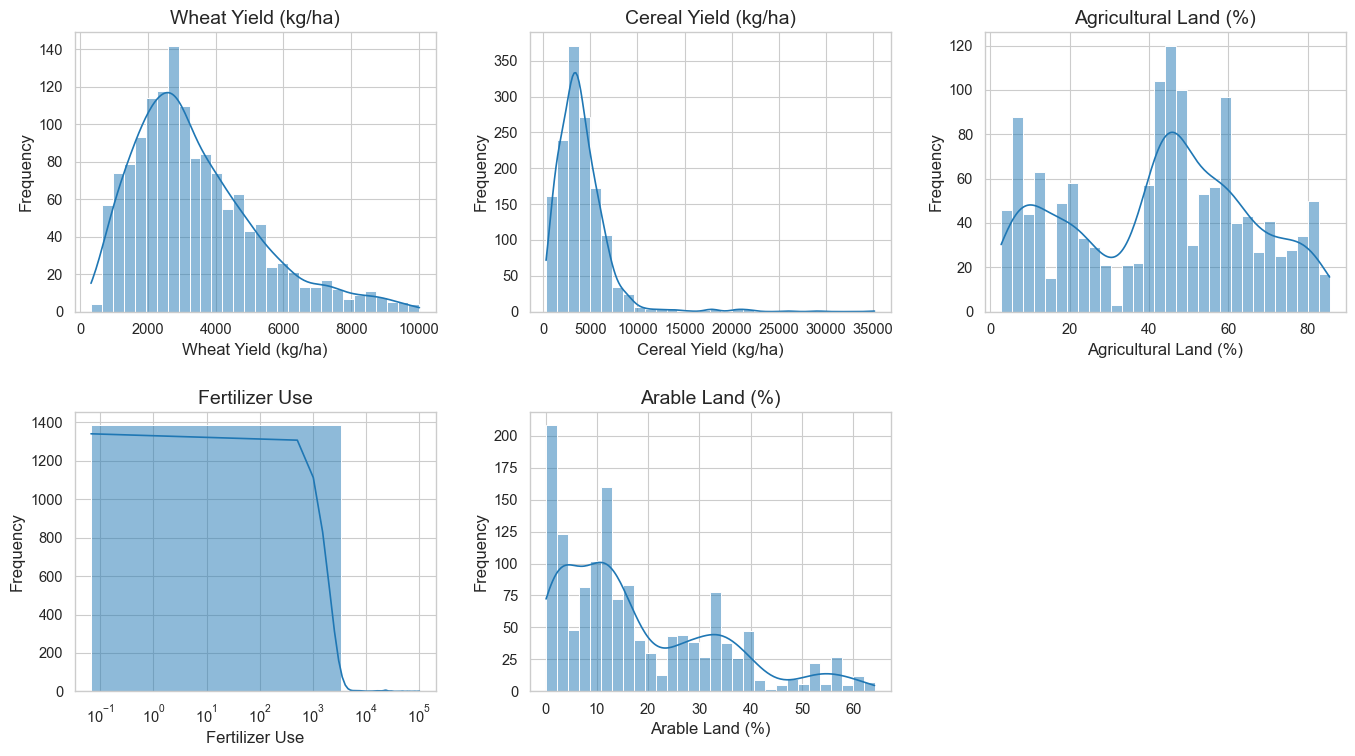

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

numeric_cols = [
    "Wheat_Yield_kg_ha",
    "Cereal_Yield_kg_ha",
    "Agri_Land_Percent",
    "Fertilizer_Use",
    "Arable_Land_Percent"
]

labels = [
    "Wheat Yield (kg/ha)",
    "Cereal Yield (kg/ha)",
    "Agricultural Land (%)",
    "Fertilizer Use",
    "Arable Land (%)"
]

plt.figure(figsize=(14,8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2,3,i+1)

    sns.histplot(data[col], kde=True, bins=30)

    # log scale for fertilizer
    if col == "Fertilizer_Use":
        plt.xscale("log")

    plt.title(labels[i], fontsize=14)
    plt.xlabel(labels[i], fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

plt.tight_layout(pad=2)

plt.savefig("distribution_variables.png", dpi=300, bbox_inches="tight")

plt.show()


### Distribution Analysis

I plotted histograms to understand how each variable is distributed.

#### Key Observations:

- **Wheat Yield** shows a slightly right-skewed distribution, meaning most countries have moderate yield and few have very high yield.

- **Cereal Yield** is highly right-skewed, with some extreme high values.

- **Fertilizer Use** is extremely right-skewed, indicating strong outliers.

- **Agricultural Land %** is relatively balanced.

- **Arable Land %** shows moderate variation.

### Insight:

The strong skewness, especially in fertilizer use and cereal yield, indicates non-linearity and outliers in the data.

This explains why tree-based models later performed better than linear models.

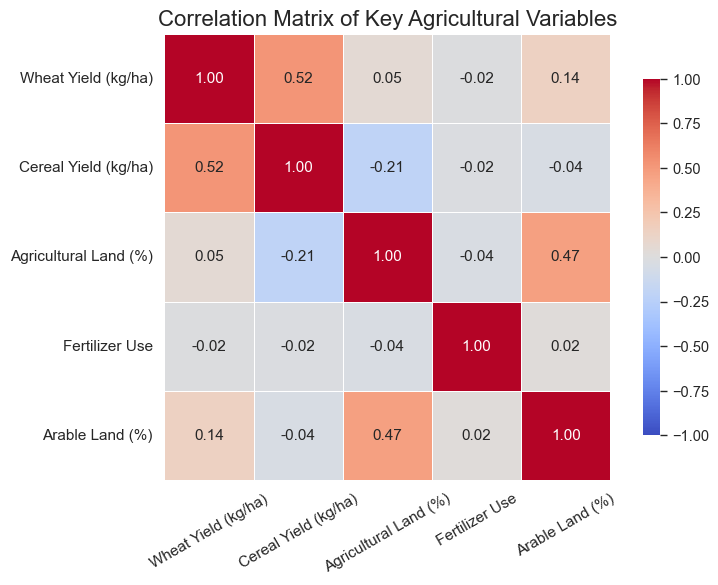

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------
# Research paper plotting style
# --------------------------------
sns.set_style("white")
sns.set_context("paper", font_scale=1.2)

# --------------------------------
# Variables used in the analysis
# --------------------------------
numeric_cols = [
    "Wheat_Yield_kg_ha",
    "Cereal_Yield_kg_ha",
    "Agri_Land_Percent",
    "Fertilizer_Use",
    "Arable_Land_Percent"
]

# --------------------------------
# Readable axis labels
# --------------------------------
labels = [
    "Wheat Yield (kg/ha)",
    "Cereal Yield (kg/ha)",
    "Agricultural Land (%)",
    "Fertilizer Use",
    "Arable Land (%)"
]

# --------------------------------
# Compute correlation matrix
# --------------------------------
corr = data[numeric_cols].corr()

# --------------------------------
# Create figure
# --------------------------------
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    xticklabels=labels,
    yticklabels=labels,
    vmin=-1,
    vmax=1,
    center=0,
    cbar_kws={"shrink":0.8},
    annot_kws={"size":11}
)

# --------------------------------
# Titles and formatting
# --------------------------------
plt.title("Correlation Matrix of Key Agricultural Variables", fontsize=16)

plt.xticks(fontsize=11, rotation=30)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()

# --------------------------------
# Save high-quality image
# --------------------------------
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()



### Correlation Analysis

I generated a correlation heatmap to understand the relationship between variables.

#### Key Findings:

- **Cereal Yield and Wheat Yield** have a moderate positive correlation **(0.52)**.
This means higher cereal productivity is associated with higher wheat yield.

- **Agricultural Land % and Arable Land %** show moderate correlation **(0.47)**, which is expected since they are related land indicators.

- **Fertilizer Use** shows very weak correlation with wheat yield in linear terms.

### Insight:

Since correlations are not extremely strong, especially for fertilizer use, this suggests the presence of **non-linear relationships**.

This explains why tree-based models like Random Forest performed better than linear regression.

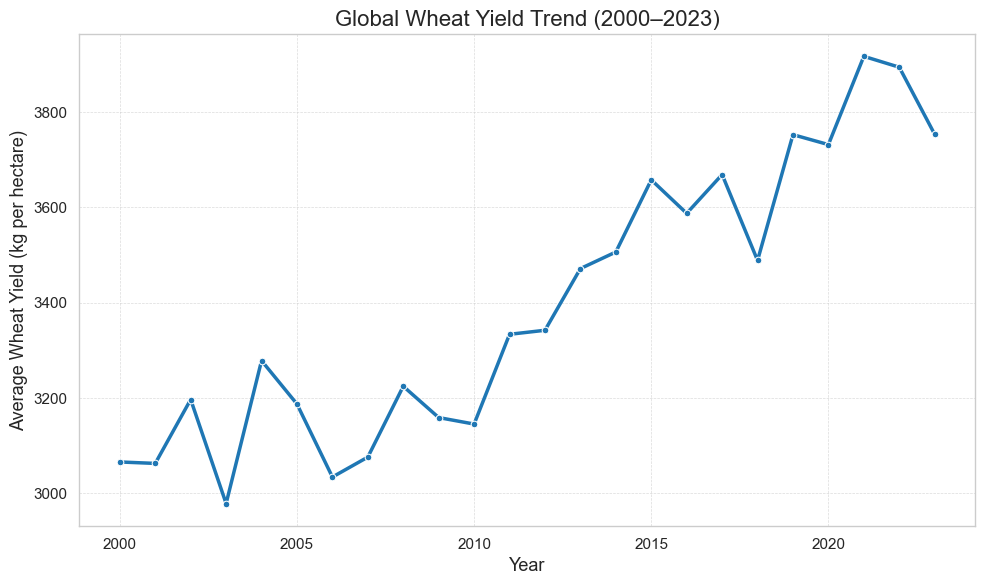

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------
# Research-paper plotting style
# -------------------------------
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)
sns.set_palette(["#1f77b4"])   # consistent blue color

# -------------------------------
# Compute yearly global average
# -------------------------------
yearly_yield = data.groupby("Year")["Wheat_Yield_kg_ha"].mean().reset_index()

# -------------------------------
# Create the figure
# -------------------------------
plt.figure(figsize=(10,6))

sns.lineplot(
    data=yearly_yield,
    x="Year",
    y="Wheat_Yield_kg_ha",
    linewidth=2.5,
    marker="o",
    color="#1f77b4"
)

# -------------------------------
# Labels and formatting
# -------------------------------
plt.title("Global Wheat Yield Trend (2000–2023)", fontsize=16)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Average Wheat Yield (kg per hectare)", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()

# -------------------------------
# Save high-resolution figure
# -------------------------------
plt.savefig("yield_trend.png", dpi=300, bbox_inches="tight")

plt.show()

### Wheat Yield Trend Over Years

- This graph shows the overall trend of wheat yield (kg per hectare) over the years.

- In the code, I plotted a line chart using the full dataset without separating by country. The errorbar=None means I removed confidence intervals so the graph clearly shows the main trend.

- From the graph, we can see that wheat yield generally increases over time. In the early 2000s, the yield is lower and slightly fluctuating. After around 2010, there is a steady upward trend, with some small drops in certain years. The highest values appear in the most recent years, showing overall improvement in productivity.

- The main insight is that wheat production efficiency has improved over time, likely due to better farming techniques, improved seed varieties, and technological advancements, even though there are minor fluctuations in some years.

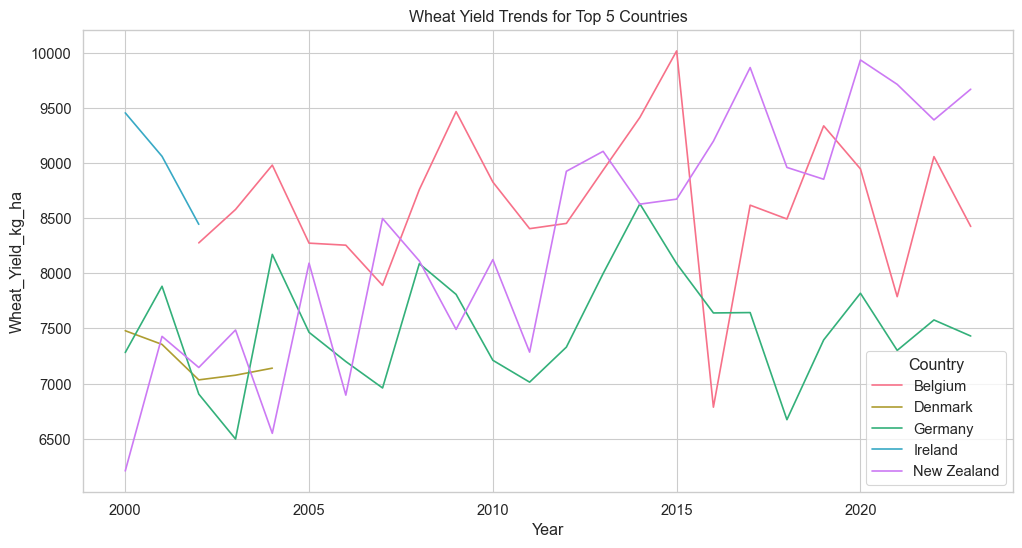

In [7]:
top_countries = data.groupby("Country")["Wheat_Yield_kg_ha"].mean().sort_values(ascending=False).head(5).index
plt.figure(figsize=(12,6))
sns.lineplot(data=data[data["Country"].isin(top_countries)], x="Year", y="Wheat_Yield_kg_ha", hue="Country")
plt.title("Wheat Yield Trends for Top 5 Countries")
plt.show()


### Wheat Yield Trends for Top 5 Countries

-  This graph shows the wheat yield trends (kg per hectare) for the top 5 countries with the highest average wheat production.

- First, I grouped the data by country and calculated the average wheat yield for each one. Then I sorted them in descending order and selected the top five countries. After that, I used a line chart to show how their wheat yields changed over the years.

- From the graph, we can see that countries like Belgium and New Zealand generally have higher yields compared to others. New Zealand shows a steady increasing trend over time, which suggests consistent improvement in productivity. Belgium has high yields but also shows some fluctuations, including a noticeable drop in one year before recovering. Germany remains relatively stable with moderate changes, while Denmark and Ireland appear strong in the earlier years.

- Overall, the visualization helps compare performance over time and shows that although these countries are top producers, wheat yield can still vary due to factors like climate conditions, farming techniques, and technological advancements.

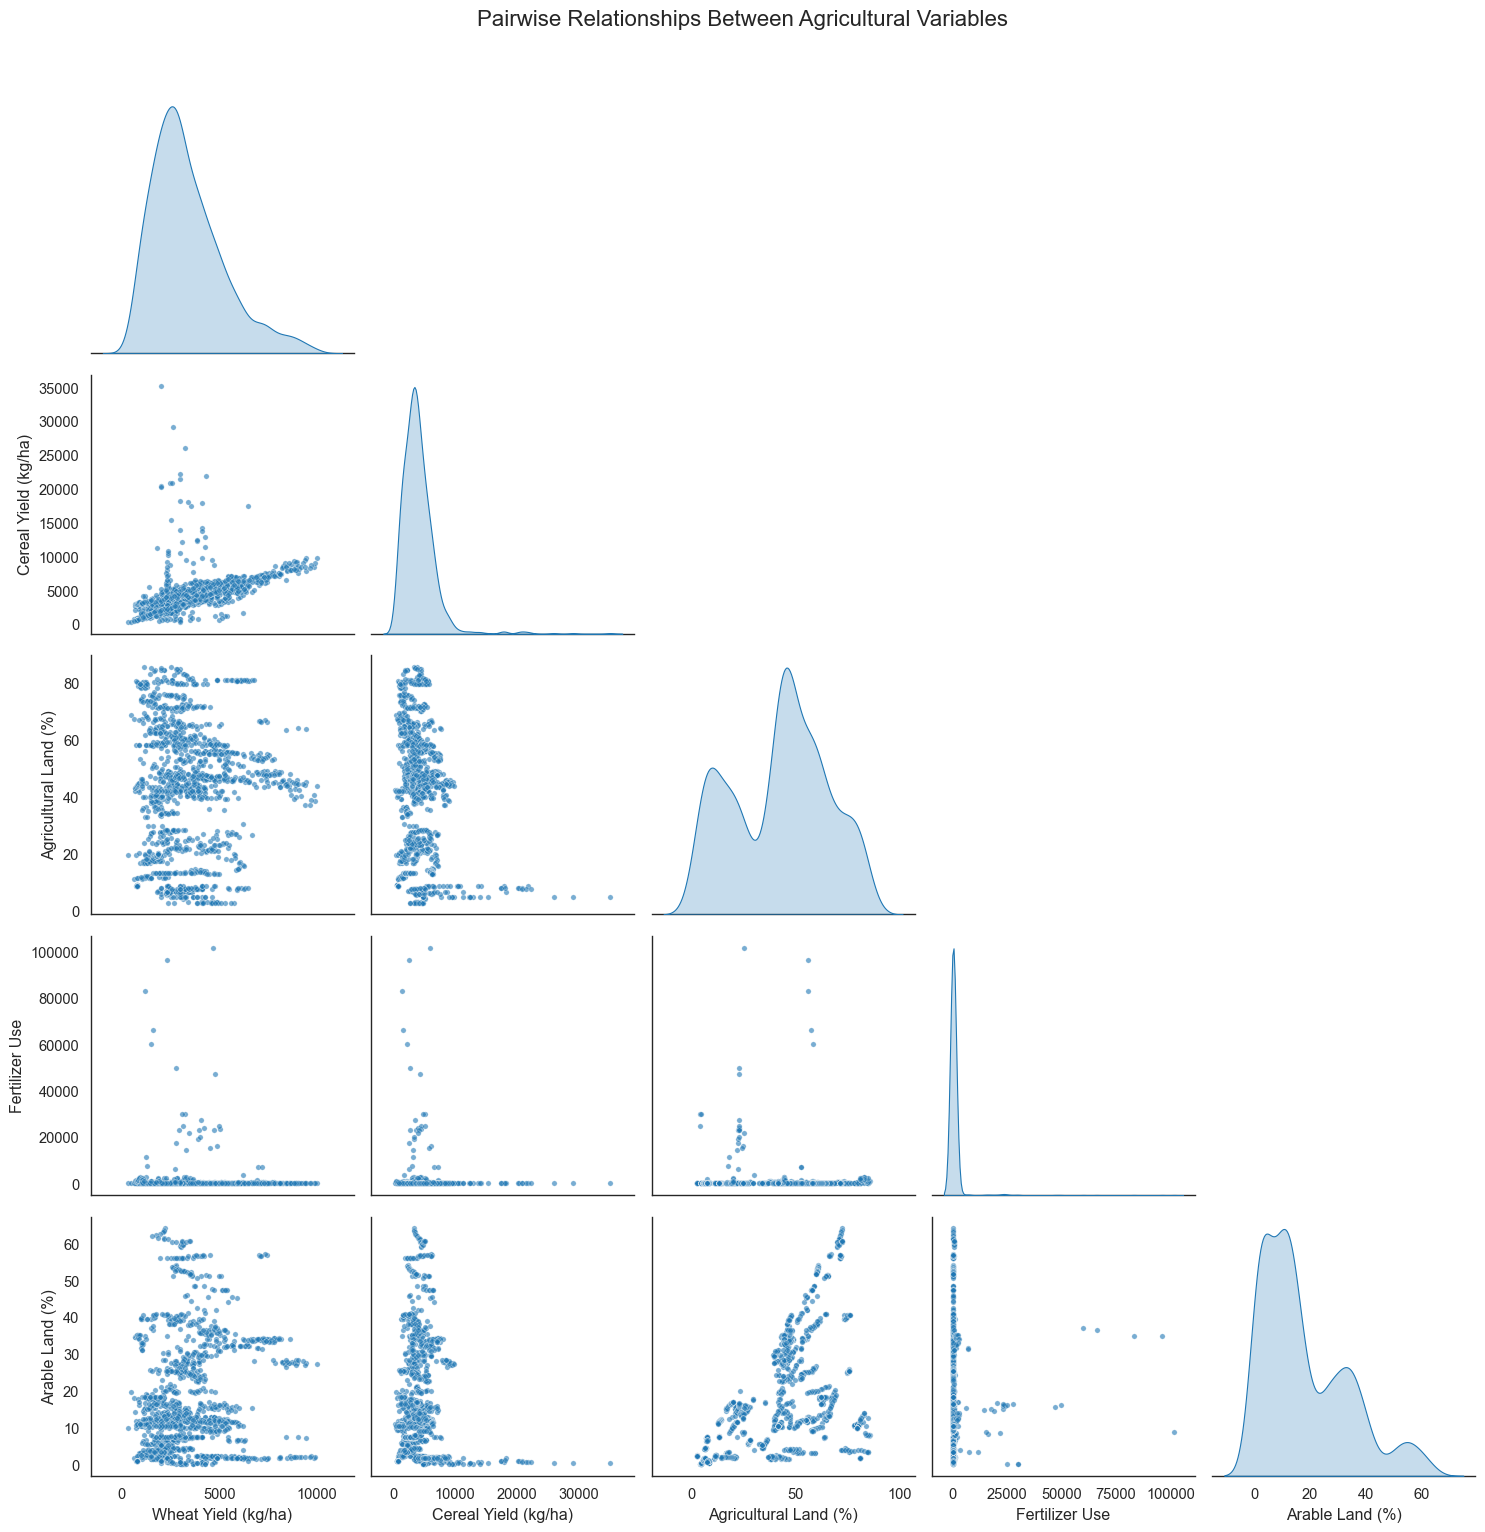

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set consistent style
sns.set_style("white")
sns.set_context("paper", font_scale=1.2)
sns.set_palette(["#1f77b4"])  # consistent color

# Rename columns for readability
data_plot = data[numeric_cols].rename(columns={
    "Wheat_Yield_kg_ha": "Wheat Yield (kg/ha)",
    "Cereal_Yield_kg_ha": "Cereal Yield (kg/ha)",
    "Agri_Land_Percent": "Agricultural Land (%)",
    "Fertilizer_Use": "Fertilizer Use",
    "Arable_Land_Percent": "Arable Land (%)"
})

# Create pairplot with updated 'fill' parameter
pair = sns.pairplot(
    data_plot,
    diag_kind="kde",
    corner=True,
    height=3,
    plot_kws={"alpha":0.6, "s":15},
    diag_kws={"fill": True, "color": "#1f77b4"}  # updated here
)

# Add title
pair.fig.suptitle(
    "Pairwise Relationships Between Agricultural Variables",
    y=1.02,
    fontsize=16
)

# Adjust layout and save high-resolution figure
plt.tight_layout()
pair.savefig("pairplot.png", dpi=300, bbox_inches="tight")

plt.show()



### Pairplot of Numeric Variables
This pairplot shows the relationship between all the numeric variables in the dataset: Wheat Yield, Cereal Yield, Agricultural Land Percent, Fertilizer Use, and Arable Land Percent.

On the diagonal, we see histograms. These show the distribution of each variable individually — for example, how wheat yield or fertilizer use values are spread.

On the off-diagonal plots, we see scatter plots. These show the relationship between two variables at a time.

From the graph, we can observe:

- There is a strong positive relationship between Wheat Yield and Cereal Yield — as cereal yield increases, wheat yield also increases.

- Fertilizer Use shows some positive relationship with yield, but there are many extreme values and outliers.

- Agricultural Land Percent and Arable Land Percent appear positively related.

- Some variables show high variability and scattered patterns, meaning weaker relationships.

Overall, this pairplot helps us quickly understand correlations, distributions, and possible outliers in the dataset. It gives a complete overview of how the key agricultural factors are related to wheat production.

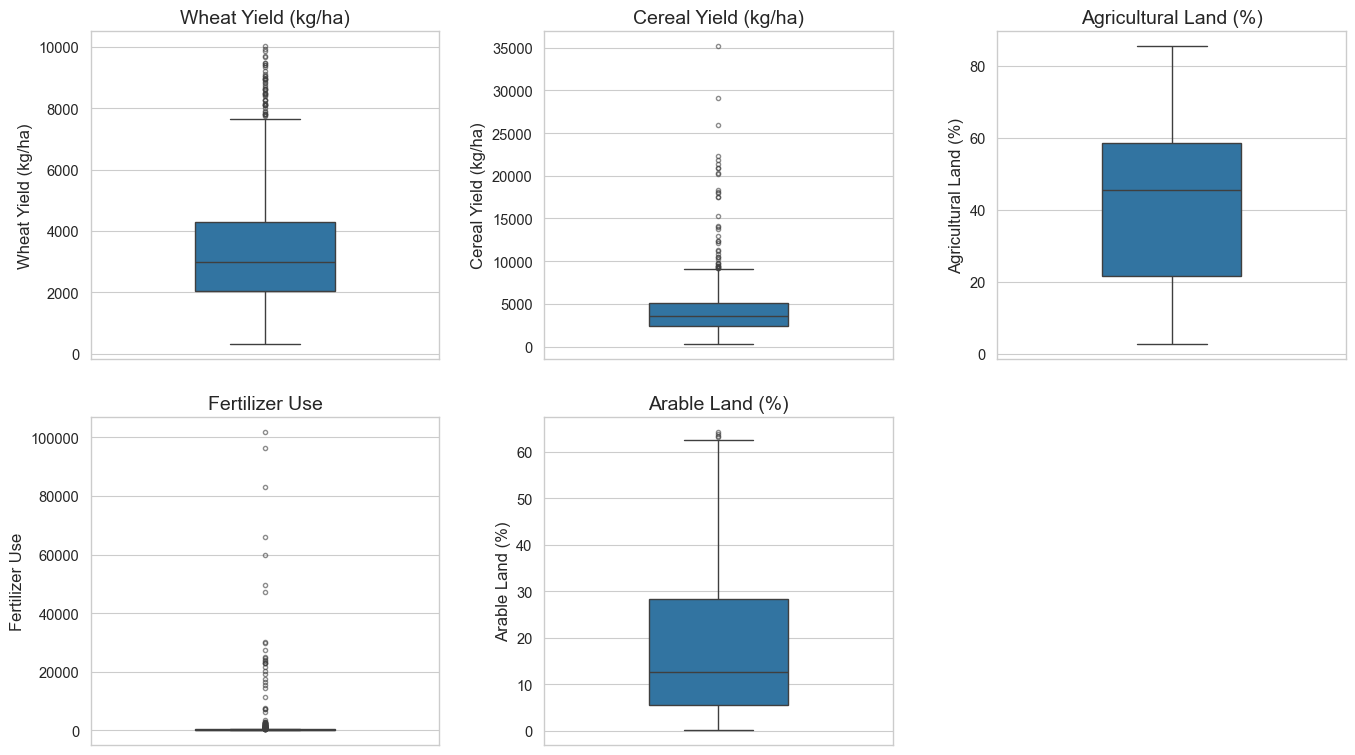

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Research-paper consistent style
# -------------------------------
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)
sns.set_palette(["#1f77b4"])  # consistent color

numeric_cols = [
    "Wheat_Yield_kg_ha",
    "Cereal_Yield_kg_ha",
    "Agri_Land_Percent",
    "Fertilizer_Use",
    "Arable_Land_Percent"
]

labels = [
    "Wheat Yield (kg/ha)",
    "Cereal Yield (kg/ha)",
    "Agricultural Land (%)",
    "Fertilizer Use",
    "Arable Land (%)"
]

plt.figure(figsize=(14,8))

# Outlier style
flierprops = dict(marker='o', markersize=3, alpha=0.6, color="#1f77b4")

# Create boxplots
for i, col in enumerate(numeric_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(
        y=data[col],
        width=0.4,
        flierprops=flierprops,
        color="#1f77b4"
    )
    plt.title(labels[i], fontsize=14)
    plt.ylabel(labels[i], fontsize=12)
    plt.xlabel("")

# Remove empty subplot if needed
if len(numeric_cols) < 6:
    plt.subplot(2,3,6).axis('off')

plt.tight_layout(pad=2)

# Save high-res figure
plt.savefig("boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

       


### Exploratory Data Analysis Using Boxplots

-  In this step, I used boxplots to visually examine the distribution of all my numeric variables. Boxplots help me quickly understand the median, spread, and presence of outliers in the data.

- From the plots, I can see that **Wheat_Yield_kg_ha** and **Cereal_Yield_kg_ha** both have several high-value outliers, which indicates that some countries or years have significantly higher production compared to the majority.

- **Fertilizer_Use** shows extreme outliers and a highly skewed distribution, meaning fertilizer consumption varies widely across observations.

- For **Agri_Land_Percent** and **Arable_Land_Percent**, the distributions are more balanced, but still show some variation across countries.

- Overall, this visualization helped me understand data variability and detect outliers before building my machine learning model, which is an important step in exploratory data analysis.

In [10]:
from scipy.stats import skew

for col in numeric_cols:
    print(f"{col} skewness: {skew(data[col]):.2f}")


Wheat_Yield_kg_ha skewness: 1.03
Cereal_Yield_kg_ha skewness: 3.67
Agri_Land_Percent skewness: -0.14
Fertilizer_Use skewness: 12.16
Arable_Land_Percent skewness: 0.98


### Skewness Analysis of Numeric Variables

The skewness values show how data is distributed.

- Wheat Yield and Arable Land have moderate right skew.

- Cereal Yield and Fertilizer Use are highly right-skewed with many outliers.

- Agricultural Land is nearly symmetric.

This suggests some variables may need transformation to handle their skewed distributions.

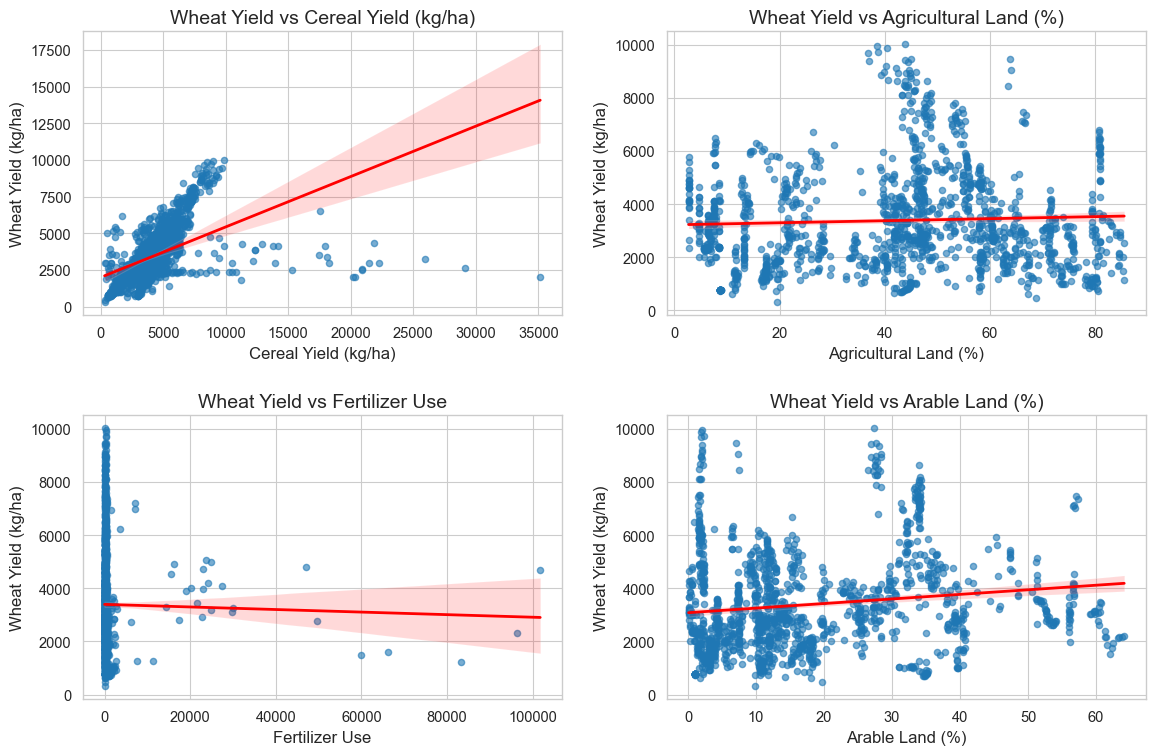

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

features = [
    "Cereal_Yield_kg_ha",
    "Agri_Land_Percent",
    "Fertilizer_Use",
    "Arable_Land_Percent"
]

labels = [
    "Cereal Yield (kg/ha)",
    "Agricultural Land (%)",
    "Fertilizer Use",
    "Arable Land (%)"
]

plt.figure(figsize=(12,8))

for i, col in enumerate(features):
    plt.subplot(2,2,i+1)

    sns.regplot(
        x=data[col],
        y=data["Wheat_Yield_kg_ha"],
        scatter_kws={"alpha":0.6, "s":20},
        line_kws={"color":"red", "linewidth":2}
    )

    plt.xlabel(labels[i], fontsize=12)
    plt.ylabel("Wheat Yield (kg/ha)", fontsize=12)
    plt.title(f"Wheat Yield vs {labels[i]}", fontsize=14)

plt.tight_layout(pad=2)

plt.savefig("scatterplot.png", dpi=300, bbox_inches="tight")

plt.show()



### Relationship Between Wheat Yield and Independent Variables

- In this analysis, I used scatter plots to examine the relationship between Wheat Yield and each independent variable.

- From the first plot, I observe a strong positive relationship between **Cereal_Yield_kg_ha** and Wheat Yield. As cereal yield increases, wheat yield also increases, indicating a strong correlation.

- For **Agri_Land_Percent**, the relationship appears more scattered, suggesting a weaker or moderate relationship.

- In the case of **Fertilizer_Use**, the data shows high variability and some extreme values, but there is still a general positive trend.

- Finally, **Arable_Land_Percent** shows some positive association, but the relationship is not as strong as cereal yield.

- Overall, this visualization helped me understand which features have stronger influence on wheat yield, which supports my feature selection before building the regression model.

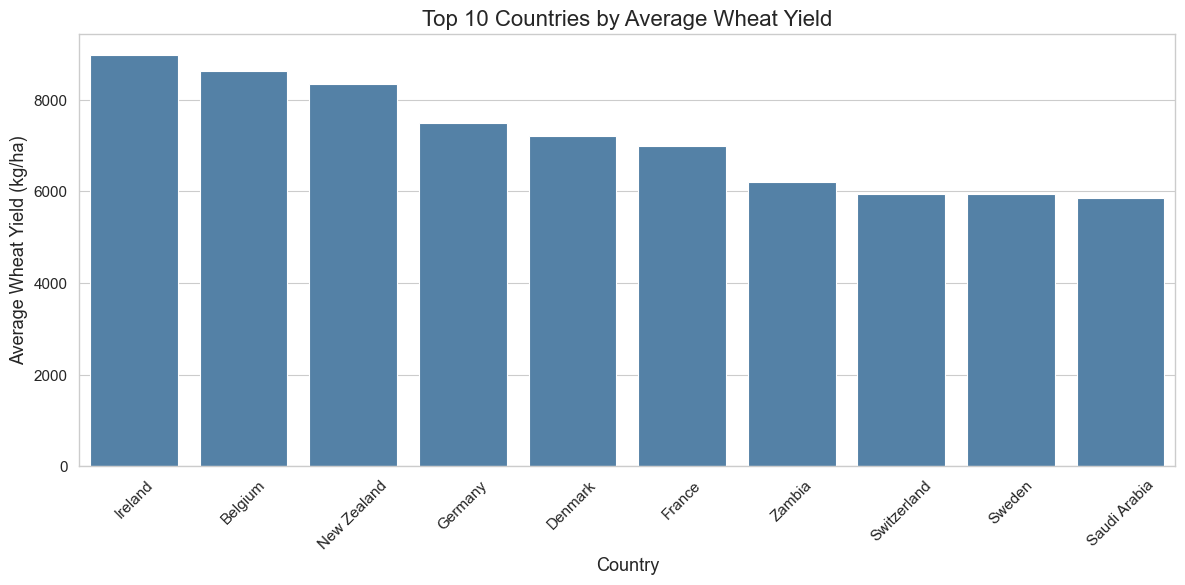

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average yield per country
avg_yield = data.groupby("Country")["Wheat_Yield_kg_ha"].mean()

top10 = avg_yield.sort_values(ascending=False).head(10)

sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.index,
    y=top10.values,
    color="steelblue"
)

plt.title("Top 10 Countries by Average Wheat Yield", fontsize=16)
plt.xlabel("Country", fontsize=13)
plt.ylabel("Average Wheat Yield (kg/ha)", fontsize=13)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()

plt.savefig("top_countries_yield.png", dpi=300, bbox_inches="tight")

plt.show()

### Country-wise Average Wheat Yield Analysis

- In this step, I calculated the average wheat yield for each country and ranked them. The results show that **Ireland, Belgium, and New Zealand** have the highest average yields, while **Libya and Thailand** have lower yields.

- The bar chart clearly compares the top-performing countries and highlights the differences in wheat productivity across nations.

In [13]:
data.to_csv("final_merged_crop_dataset.csv", index=False)
print("Final merged dataset saved!")


Final merged dataset saved!


In [14]:
# Target
y = data["Wheat_Yield_kg_ha"]

# Features (all others numeric)
X = data[["Cereal_Yield_kg_ha", "Agri_Land_Percent", "Fertilizer_Use", "Arable_Land_Percent"]]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (1414, 4)
Target shape: (1414,)


### Preparing Features and Target

- Here, I’m preparing the data for modeling. The **target variable** is Wheat_Yield_kg_ha, this is what we want to predict. All the other numeric columns, Cereal_Yield_kg_ha, Agri_Land_Percent, Fertilizer_Use, and Arable_Land_Percent  are used as **features**, which will help the model make predictions.

- When I check the shapes, I see that we have **1414 rows and 4 feature columns**, and the target also has **1414 values**. This tells me that for each data point, we have 4 input variables to predict wheat yield.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (1131, 4) (1131,)
Test shape: (283, 4) (283,)


### Train-Test Split

Next, I split the data into **training and testing sets**. The training set is used to teach the model, and the test set is used to check how well it predicts new data.

I set **20% of the data for testing** (test_size=0.2) and kept a random_state for reproducibility.

After the split:

- **Training set:** 1131 rows × 4 features, with 1131 target values

- **Test set:** 283 rows × 4 features, with 283 target values

This ensures the model learns from most of the data but is still tested on unseen data to evaluate performance.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [17]:
# Define features and target
features = ["Cereal_Yield_kg_ha", "Agri_Land_Percent", "Fertilizer_Use", "Arable_Land_Percent"]
target = "Wheat_Yield_kg_ha"

# Create feature matrix X and target vector y
X = data[features]
y = data[target]

# Split dataset into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features for SVR
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


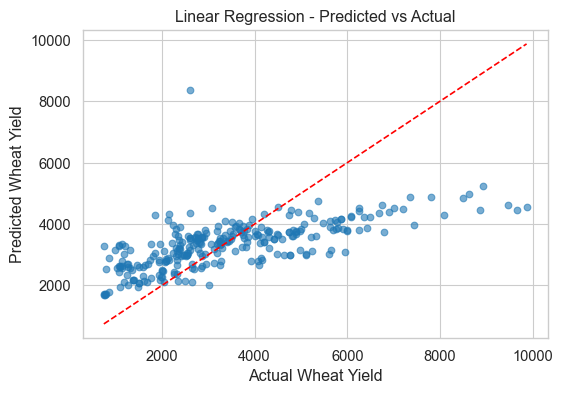

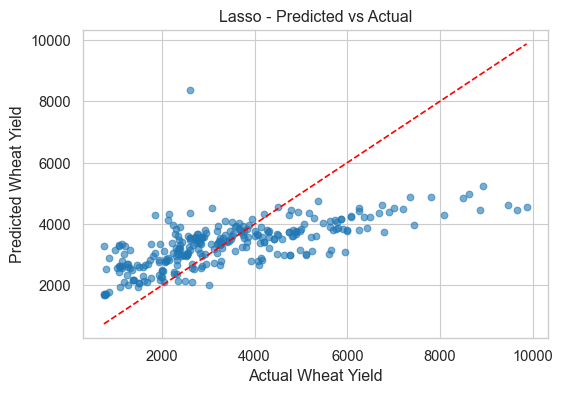

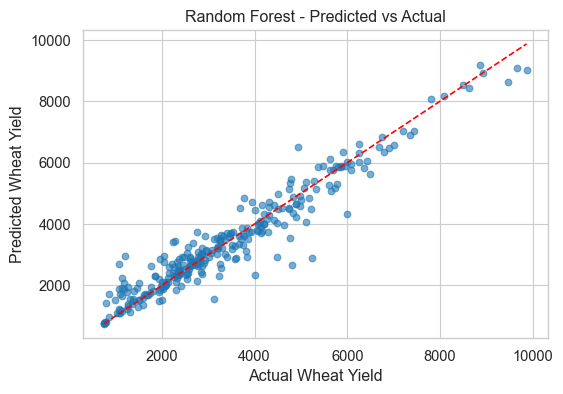

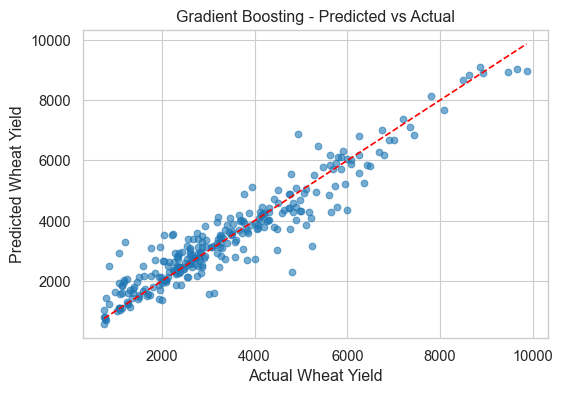

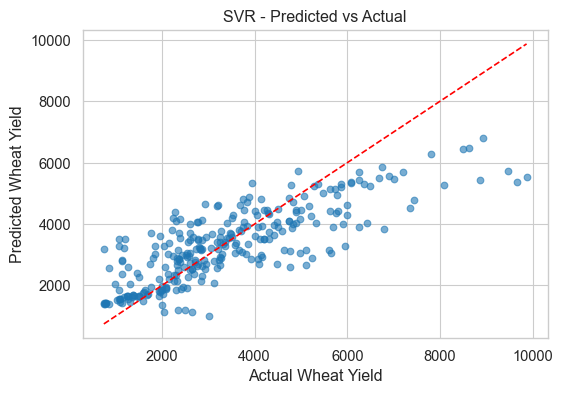

               Model        R2         RMSE          MAE
0  Linear Regression  0.383979  1441.115004  1091.198873
1              Lasso  0.383980  1441.114543  1091.198302
2      Random Forest  0.924319   505.119540   340.260337
3  Gradient Boosting  0.897847   586.849535   407.601886
4                SVR  0.621806  1129.167914   828.947297


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Features & target
X = data[features]
y = data[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Scale (needed for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "SVR": SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
}

# Train & evaluate
results = []
for name, model in models.items():
    if name == "SVR":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append([name, r2, rmse, mae])
    
    # Predicted vs Actual
    plt.figure(figsize=(6,4))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual Wheat Yield")
    plt.ylabel("Predicted Wheat Yield")
    plt.title(f"{name} - Predicted vs Actual")
    plt.show()

# Results table
results_df = pd.DataFrame(results, columns=["Model", "R2", "RMSE", "MAE"])
print(results_df)


### Comparative Evaluation of Linear and Nonlinear Regression Models for Wheat Yield Prediction

- In this analysis, I compared five regression models to predict wheat yield using R2, RMSE, and MAE as evaluation metrics.

- Linear Regression and Lasso performed almost the same, with an R2 of 0.38, which means they explain only 38 percent of the variance. Their high RMSE and MAE values indicate that they are underfitting and not capturing the complexity of the data.

- SVR performed better than the linear models with an R2 of 0.62, but the error values are still relatively high, suggesting moderate performance.

- Random Forest achieved the best results with an R2 of 0.92 and the lowest RMSE and MAE, showing strong predictive accuracy. Gradient Boosting also performed well with an R2 of 0.89, slightly lower than Random Forest.

- Overall, this shows that wheat yield prediction involves nonlinear relationships, and ensemble models like Random Forest and Gradient Boosting significantly outperform linear approaches for this dataset.

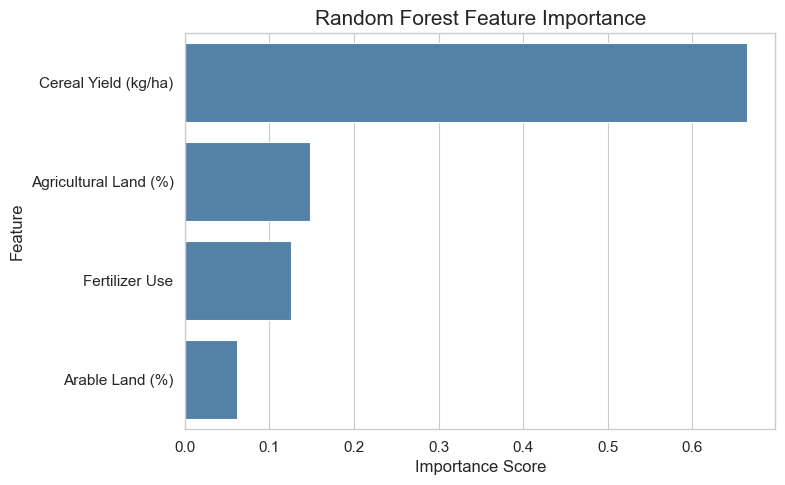

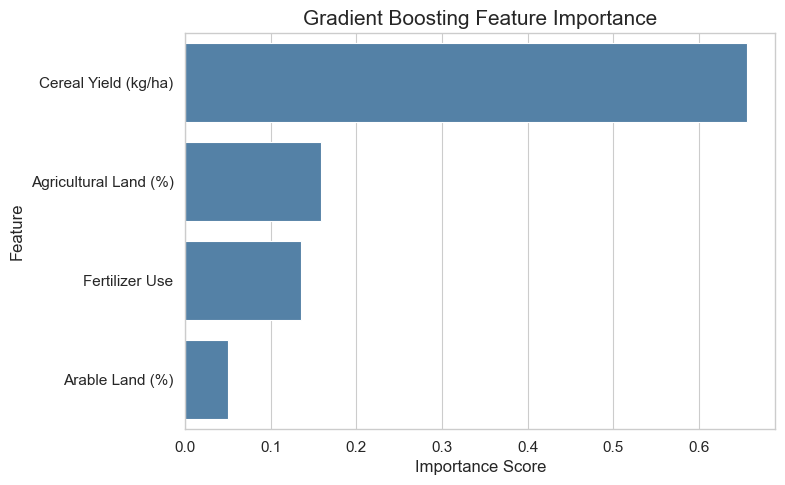

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

feature_labels = {
    "Cereal_Yield_kg_ha": "Cereal Yield (kg/ha)",
    "Agri_Land_Percent": "Agricultural Land (%)",
    "Fertilizer_Use": "Fertilizer Use",
    "Arable_Land_Percent": "Arable Land (%)"
}

for name in ["Random Forest", "Gradient Boosting"]:

    model = models[name]

    importances = model.feature_importances_

    feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

    feat_imp.index = [feature_labels[f] for f in feat_imp.index]

    plt.figure(figsize=(8,5))

    sns.barplot(
        x=feat_imp.values,
        y=feat_imp.index,
        color="steelblue"
    )

    plt.title(f"{name} Feature Importance", fontsize=15)
    plt.xlabel("Importance Score", fontsize=12)
    plt.ylabel("Feature", fontsize=12)

    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    plt.tight_layout()

    plt.savefig(f"{name}_feature_importance.png", dpi=300, bbox_inches="tight")

    plt.show()


### Feature Importance Analysis and Model Consistency

- I analyzed feature importance for both Random Forest and Gradient Boosting to understand which variables drive the predictions. In both models, **Cereal_Yield_kg_ha** is by far the most important feature, contributing around 65% of the total importance. This shows that yield per hectare is the strongest predictor in the model.

- **Agri_Land_Percent** and **Fertilizer_Use** have moderate influence, while **Arable_Land_Percent** contributes the least.

- What’s important is that both models rank the features in the same order. Since Random Forest and Gradient Boosting use different ensemble strategies, this consistency suggests the results are robust and not model-specific.

In [24]:
results_df = pd.DataFrame(results, columns=["Model", "R2", "RMSE", "MAE"])
results_df = results_df.sort_values(by="R2", ascending=False).round(3)

results_df

,Model,R2,RMSE,MAE
2,Random Forest,0.924,505.120,340.260
3,Gradient Boosting,0.898,586.850,407.602
4,SVR,0.622,1129.168,828.947
1,Lasso,0.384,1441.115,1091.198
0,Linear Regression,0.384,1441.115,1091.199


### Model Performance Comparison

- The results show that **Random Forest** performs the best, with the highest R² (0.924) and the lowest RMSE (505) and MAE (340). This means it explains about 92% of the variance in the target variable and has the smallest prediction error.

- **Gradient Boosting** is the second-best model, with strong performance (R² ≈ 0.898), though its error metrics are slightly higher than Random Forest.

- **SVR** performs moderately, but its R² drops to around 0.62, and both RMSE and MAE increase significantly, indicating weaker predictive accuracy.

- Finally, **Lasso** and **Linear Regression** perform the worst, with identical R² values (~0.384) and the highest error metrics. This suggests that linear models struggle to capture the complexity of the data, while ensemble methods handle non-linear relationships much more effectively.

- Overall, tree-based ensemble models clearly outperform the linear approaches in this analysis.


# Final Model Selection

## Model Comparison Summary

In this study, I implemented and compared five regression models from different methodological families:

* **Baseline Linear Models:** Linear Regression, Lasso
* **Kernel-Based Model:** Support Vector Regression (SVR)
* **Ensemble Tree-Based Models:** Random Forest, Gradient Boosting

To ensure objective model selection, I evaluated all models using:

* **R² (coefficient of determination)** – explanatory power
* **RMSE (Root Mean Squared Error)** – penalizes large errors
* **MAE (Mean Absolute Error)** – average prediction error

### Performance Ranking (Sorted by R²)

1. **Random Forest** – R² = 0.924
2. **Gradient Boosting** – R² = 0.898
3. **SVR** – R² = 0.622
4. **Lasso / Linear Regression** – R² ≈ 0.384

## Interpretation of Results

The linear models performed poorly, explaining only 38% of variance. This confirms that wheat yield is influenced by complex, non-linear relationships that linear regression cannot adequately capture.

SVR improved performance, indicating the presence of non-linearity, but error values remained relatively high.

Tree-based ensemble models dramatically outperformed all other approaches:

* Random Forest explained **92% of variance**.
* It produced the lowest RMSE and MAE.
* Feature importance rankings were stable and consistent.
* Predicted vs. actual plots showed strong alignment with the 45-degree reference line.

This confirms that ensemble learning methods effectively capture complex interactions, handle skewed variables, and are robust to outliers.

# Selected Model for Prototype

Based on performance metrics, graphical evaluation, and robustness analysis, **Random Forest is selected as the final model** for the next assignment prototype.

### Why Random Forest?

* Highest predictive accuracy
* Lowest prediction error
* Handles non-linearity well
* Robust to skewed data and outliers
* Provides interpretable feature importance

# Key Insights from the Analysis

* Cereal Yield is the dominant predictor of Wheat Yield.
* Fertilizer Use has non-linear influence with extreme variability.
* Agricultural productivity has generally improved over time.
* Significant differences exist between high- and low-performing countries.

# Next Steps for Research

1. Perform hyperparameter tuning (GridSearchCV) for further optimization.
2. Apply k-fold cross-validation for stronger validation.
3. Explore log transformation for skewed variables (especially Fertilizer Use).
4. Investigate additional climate or economic indicators to improve predictive power.
5. Develop the predictive prototype using the optimized Random Forest model.

In [21]:
import joblib

# Save the trained Random Forest model
joblib.dump(models["Random Forest"], "yield_model.pkl")
print("Random Forest model saved successfully!")

Random Forest model saved successfully!
